In [ ]:
run_scraper = False # this is a check to prevent the scraper from running everytime run all is selected. To run the scraper change the value to True

# arXiv Astrophysics Scraper and Data Analysis

## Introduction
Built a robust web scraper with Selenium to collect metadata from 19,000+ astrophysics papers on arXiv.org, handling CAPTCHA and complex pagination. Performed a comprehensive data analysis using pandas to identify and visualize trends in publication cycles, collaboration size, and subject popularity.

## Scraper

In this section, I created the code for the scraper using selenium and python. Using selenium I created a virtual browser which accessed each primary search page and then visited the abstract page for every article. From the main page I pulled the Author, Abstract link, Title and Subject. From the abstract pages, I pulled a link to the full PDF, the alternate DOI (if there was one), and the first and last submission dates. Finally I compiled these into a list of dictionaries and passed that to a pandas dataframe which exported the information to a .xlsx document.

In [ ]:
from selenium import webdriver
import pandas as pd
import time
from bs4 import BeautifulSoup
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import random

if run_scraper:
    driver = webdriver.Chrome()
    start_url = "https://arxiv.org/list/astro-ph/2024"
    all_papers_data = []

    visited_urls = set() #set to store URLs already scraped
    link_list = [] #create a list to store links to visit later

    # Initial Page Load & Captcha
    print("Loading initial page...")
    driver.get(start_url)
    print("Browser opened. Please solve any CAPTCHA if present.")

    # Wait for main content 
    try:
        WebDriverWait(driver, 300).until(
            EC.presence_of_element_located((By.ID, "articles"))
        )
        print("Main content detected. Continuing script...")
    except Exception as e:
        print("Times out waiting for page to load after CAPTCHA.")
        driver.quit()

    def get_next_date_string(tag):
        # Function to find next non-whitespace sibling string after a given tag.\
        node = tag.next_sibling
        while node and not str(node).strip():
            node = node.next_sibling
        if node:
            return str(node).strip()
        return ""

    # While loop to go through every page and scrape the data
    while True:
        try:
            WebDriverWait(driver, 300).until(
                EC.presence_of_element_located((By.ID, "articles"))
            )
        except Exception as e:
            print("Timed out waiting for page content or CAPTCHA. Ending script.")
            break

        current_url = driver.current_url
        if current_url in visited_urls:
            print("Duplicate URL detected. Ending loop to prevent getting stuck.")
            break
        visited_urls.add(current_url)
        print(f"Scraping page: {current_url}")

        page_html = driver.page_source

        # create the soup variable with the lxml parser

        soup = BeautifulSoup(page_html, 'lxml')

        all_dt_tags = soup.find_all('dt')
        all_dd_tags = soup.find_all('dd')

        #scrape abstract, titles and author data from website
        for i in range(len(all_dt_tags)):
            try:
                abstract_links = all_dt_tags[i].find('a', title='Abstract')
                relative_link = abstract_links['href']
                full_link = "https://arxiv.org" + relative_link
                link_list.append(full_link) # add each abstract link to the full link list
                
                # Scrape title data
                title_div = all_dd_tags[i].find('div', class_='list-title')
                clean_title = title_div.text.strip().replace('Title:\n', '')
                
                # Scrape author data
                authors_div = all_dd_tags[i].find('div', class_='list-authors')
                author_tags = authors_div.find_all('a')
                authors_list = [author.text.strip() for author in author_tags]

                # Scrape subject data
                subject_div = all_dd_tags[i].find('div', class_='list-subjects')
                clean_subject = subject_div.text.strip().replace('Subjects:\n', '')

                #navigates to link found in abstract
                driver.get(full_link) 
                time.sleep(random.uniform(0.75, 1.5))
                try:
                    WebDriverWait(driver, 300).until(
                        EC.presence_of_element_located((By.CLASS_NAME, "submission-history"))
                    )
                except Exception as e:
                    print("Timed out waiting for page content or CAPTCHA. Ending script.")
                    continue
                detail_html = driver.page_source
                detail_soup = BeautifulSoup(detail_html, 'lxml')
                
                # scrape DOI numbers
                doi_link = ""
                doi_td = detail_soup.find('td', class_="tablecell doi")
                if doi_td:
                    doi_tags = doi_td.find('a')
                    if doi_tags:
                        doi_link = doi_tags['href']

                # scrape submission data
                first_submission = ""
                most_recent_submission = ""
                submission_div = detail_soup.find('div', class_="submission-history") #locate div class
                if submission_div:
                    submission_tags = submission_div.find_all('strong') #create a list of all strong classes
                    if submission_tags:
                        first_submission = get_next_date_string(submission_tags[0])
                        most_recent_submission = get_next_date_string(submission_tags[-1])

                # scrape PDF link
                pdf_link = ""
                pdf_div = detail_soup.find('div', class_="full-text")
                if pdf_div:
                    pdf_tags = pdf_div.find_all('li')
                    for pdf_tag in pdf_tags:
                        if "PDF" in pdf_tag.text:
                            pdf_link_tag = pdf_tag.find('a')
                            break
                    if pdf_link_tag and pdf_link_tag.has_attr('href'):
                        pdf_link = "https://arxiv.org" + pdf_link_tag['href']


                #store data in dictionary
                all_papers_data.append({
                    'title': clean_title,
                    'authors': authors_list,
                    'link': full_link,
                    'subject': clean_subject,
                    'doi': doi_link,
                    'submission_v1' : first_submission,
                    'submission_most_recent': most_recent_submission,
                    'pdf_link' : pdf_link
                })
            except Exception as e:
                print(f"Skipping a paper due to an error: {e}")
                continue
            

        # pagination logic
        next_page_tag = None 

        #checking if there is a Next button, if not changing pagination methods
        pagination_div = soup.find('div', class_='paging')

        if pagination_div:
            all_markers = pagination_div.find_all('span')

                #find the current page
            for marker in all_markers:
                if '-' in marker.text:
                    current_page_node = marker
                break
                # Find the very next link after the current page node
            if current_page_node:
                next_page_tag = current_page_node.find_next_sibling('a')



        if next_page_tag and next_page_tag.has_attr('href'):
            next_page_url = "https://arxiv.org" + next_page_tag['href']
            driver.get(next_page_url)
            time.sleep(random.uniform(0.75, 1.5)) #politeness delay
        else: 
            print("Last page reached. Scraping complete.")
            current_url = None
            break
    driver.quit()
        

    #create a pandas dataframe of the scraped data
    df = pd.DataFrame(all_papers_data)

    #save the dataframe to an excel file
    df.to_excel('arxiv_astrophysics_papers.xlsx', index=False)

    print("Scraping complete! Data saved to 'arxiv_astrophysics_papers.xlsx'")

    df.head()
else:
    print("Scraping skipped. Loading data from existing file")

Scraping skipped. Loading data from existing file


## Data Analysis

### Initial Setup

After collecting the data into an excel file, I performed data analysis on it. I start the analysis by loading a dataframe from the excel document.

In [2]:
df = pd.read_excel('arxiv_astrophysics_papers.xlsx')

df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19226 entries, 0 to 19225
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   title                   19226 non-null  object
 1   authors                 19226 non-null  object
 2   link                    19226 non-null  object
 3   subject                 19226 non-null  object
 4   doi                     7975 non-null   object
 5   submission_v1           19226 non-null  object
 6   submission_most_recent  19226 non-null  object
 7   pdf_link                19226 non-null  object
dtypes: object(8)
memory usage: 1.2+ MB


### Cleaning and Converting submission details

The submission dates all ended with the size of the file that was uploaded. I created a function to clean the text from each submission date as well as to convert the data type to datetime. I then used .apply() to apply this function to every entry in the submission date columns.

In [3]:
import re

def clean_and_convert_date(date_string):
    if not isinstance(date_string, str):
        return None
    # Use a regular expression to remove the part of the string after UTC
    match = re.search(r'.+UTC', date_string)
    # If there is a match string created, convert to datetime
    if match:
        return pd.to_datetime(match.group())
    return None

df['submission_v1'] = df['submission_v1'].apply(clean_and_convert_date)
df['submission_most_recent'] = df['submission_most_recent'].apply(clean_and_convert_date)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19226 entries, 0 to 19225
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   19226 non-null  object             
 1   authors                 19226 non-null  object             
 2   link                    19226 non-null  object             
 3   subject                 19226 non-null  object             
 4   doi                     7975 non-null   object             
 5   submission_v1           19226 non-null  datetime64[ns, UTC]
 6   submission_most_recent  19226 non-null  datetime64[ns, UTC]
 7   pdf_link                19226 non-null  object             
dtypes: datetime64[ns, UTC](2), object(6)
memory usage: 1.2+ MB


### Cleaning Authors and Calculating the Most Prolific Author

Started by converting the strings of data in the author column to actual lists and verified that it had an updated data type. I then created a dataframe that counted the number of papers written by each author. Displayed a list of the top 10 most prolific authors. Finally I calculated the average authors per paper.

In [4]:
import ast

# convert the string representation of a list to an actual python list
df['authors'] = df['authors'].apply(ast.literal_eval)

print(f"The new data type for the authors column is: {type(df['authors'].iloc[0])}")

df.head()

authors_df = df.explode('authors')

authors_df.head()

# determine the authors who have authored or coauthored the most papers
author_counts = authors_df['authors'].value_counts()

print("Top 10 most prolific authors:")
print(author_counts.head(10))

# calculate the averate authors per paper
total_author_entries = len(authors_df)
total_unique_papers = len(df)
average_authors_per_paper = total_author_entries / total_unique_papers
print(f"\nAverage number of authors per paper: {average_authors_per_paper:.2f}")

The new data type for the authors column is: <class 'list'>
Top 10 most prolific authors:
authors
D. Brooks           100
R. Miquel            92
E. Sanchez           89
K. Honscheid         86
P. Doel              80
J. Carretero         80
M. Schubnell         70
T. Claybaugh         67
S. Ahlen             67
A. de la Macorra     67
Name: count, dtype: int64

Average number of authors per paper: 8.97


### Calculating the Papers Published per Month.

Using the groupby() function I created a variable that first created groups for each month of the year, and then calculated the size of those groups. Filtered out the 43 papers that were published in 2023 that were pulled by the scraper. Then created a bar graph showing how many papers were publish in each month of 2024. Analysis indicates that October was the most prolific month for papers in 2024.

Number of papers submitted per month:
submission_v1
2023-10-31 00:00:00+00:00       1
2023-11-30 00:00:00+00:00       3
2023-12-31 00:00:00+00:00      39
2024-01-31 00:00:00+00:00    1568
2024-02-29 00:00:00+00:00    1372
2024-03-31 00:00:00+00:00    1468
2024-04-30 00:00:00+00:00    1594
2024-05-31 00:00:00+00:00    1717
2024-06-30 00:00:00+00:00    1593
2024-07-31 00:00:00+00:00    1742
2024-08-31 00:00:00+00:00    1370
2024-09-30 00:00:00+00:00    1696
2024-10-31 00:00:00+00:00    1922
2024-11-30 00:00:00+00:00    1632
2024-12-31 00:00:00+00:00    1509
Freq: ME, dtype: int64


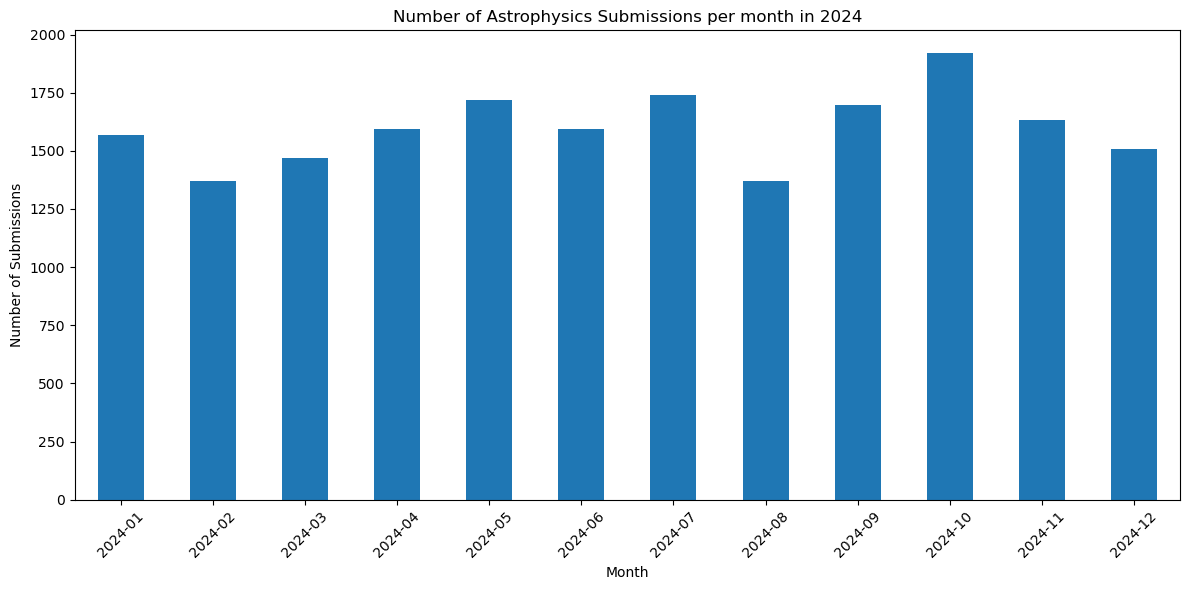

In [5]:
import matplotlib.pyplot as plt

# Creates a dataframe with the index changed to the values of the submission_v1 column
df_time = df.set_index('submission_v1')

# Groups and counts the papers completed each month
monthly_counts = df_time.groupby(pd.Grouper(freq='ME')).size()

print("Number of papers submitted per month:")
print(monthly_counts)

# Filter out the papers that slipped by that were published in 2023
counts_2024 = monthly_counts[monthly_counts.index.year == 2024]

# Creates a bar chart of the data
ax = counts_2024.plot(kind='bar', figsize=(12, 6), rot=45)

ax.set_xticklabels([d.strftime('%Y-%m') for d in counts_2024.index])

# Add title and lables to chart
plt.title('Number of Astrophysics Submissions per month in 2024')
plt.xlabel('Month')
plt.ylabel('Number of Submissions')

plt.tight_layout()

plt.show()

### Clean the Subject List and Calculate the Most Popular Subject of 2024

I started by cleaning the subject list and removing everything after the primary subject. I then stored these in a new column named "primary_subject". I then filtered the subject list to exclude tangentially related subjects focusing on only Astrophysics, General Relativity and Quantum Cosmology, and High Energy Physics. I chose to include General Relativity and Quantum Cosmology as well as High Energy Physics due to their association with Astrophysics. Finally I calculated the number of papers published in every remaining subject and plotted them on a horizontal bar chart.

Number of unique astrophysics subjects after filtering:
9


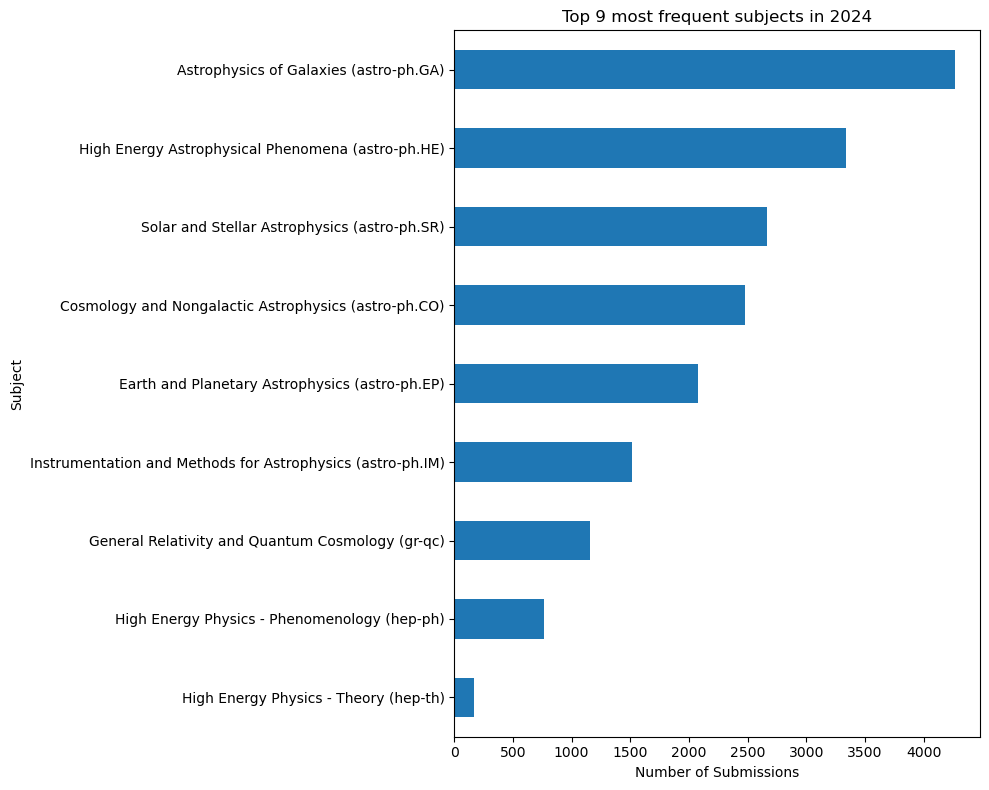

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19226 entries, 0 to 19225
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   19226 non-null  object             
 1   authors                 19226 non-null  object             
 2   link                    19226 non-null  object             
 3   subject                 19226 non-null  object             
 4   doi                     7975 non-null   object             
 5   submission_v1           19226 non-null  datetime64[ns, UTC]
 6   submission_most_recent  19226 non-null  datetime64[ns, UTC]
 7   pdf_link                19226 non-null  object             
 8   primary_subject         19226 non-null  object             
dtypes: datetime64[ns, UTC](2), object(7)
memory usage: 1.3+ MB


In [6]:
# Clean the subject columnn to only include the primary subject.
df['primary_subject'] = df['subject'].str.split(';').str[0].str.strip()

df[['subject', 'primary_subject']].head()

astro_df = df[
    (df['primary_subject'].str.contains('astro-ph', na=False)) |
    (df['primary_subject'].str.contains('gr-qc', na=False)) |
    (df['primary_subject'].str.contains('hep-ph', na=False)) |
    (df['primary_subject'].str.contains('hep-th', na=False))
].copy()

print("Number of unique astrophysics subjects after filtering:")
print(astro_df['primary_subject'].nunique())

subject_counts = astro_df['primary_subject'].value_counts()
subject_counts.head(9)

subject_counts.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Top 9 most frequent subjects in 2024')
plt.xlabel('Number of Submissions')
plt.ylabel('Subject')

plt.tight_layout()

plt.show()

df.info()

### Comparing the Average Revision Time per Subject

I had the question of how much the subject of a paper influenced the time from the first version to the final revision. I started by filtering the submission_most_recent column to exclude any papers where the first submission date matched the most recent revision date. I then applied the same subject filtering as I did in the previous step. I updated the filtered dataframe to only include the papers that had multiple submissions. Finally using .groupby() and .mean() I calculated the average revision time by subject and sorted them in ascending order. I finalized the product by plotting them on a horizontal bar graph and observed that there actually is a considerable difference in the revision times for each subject.

<class 'pandas.core.frame.DataFrame'>
Index: 7273 entries, 2 to 19225
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   7273 non-null   object             
 1   authors                 7273 non-null   object             
 2   link                    7273 non-null   object             
 3   subject                 7273 non-null   object             
 4   doi                     3987 non-null   object             
 5   submission_v1           7273 non-null   datetime64[ns, UTC]
 6   submission_most_recent  7273 non-null   datetime64[ns, UTC]
 7   pdf_link                7273 non-null   object             
 8   primary_subject         7273 non-null   object             
dtypes: datetime64[ns, UTC](2), object(7)
memory usage: 568.2+ KB


C:\Users\thatp\AppData\Local\Temp\ipykernel_37936\2967131392.py:12: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  revised_df = revised_df[


<function matplotlib.pyplot.show(close=None, block=None)>

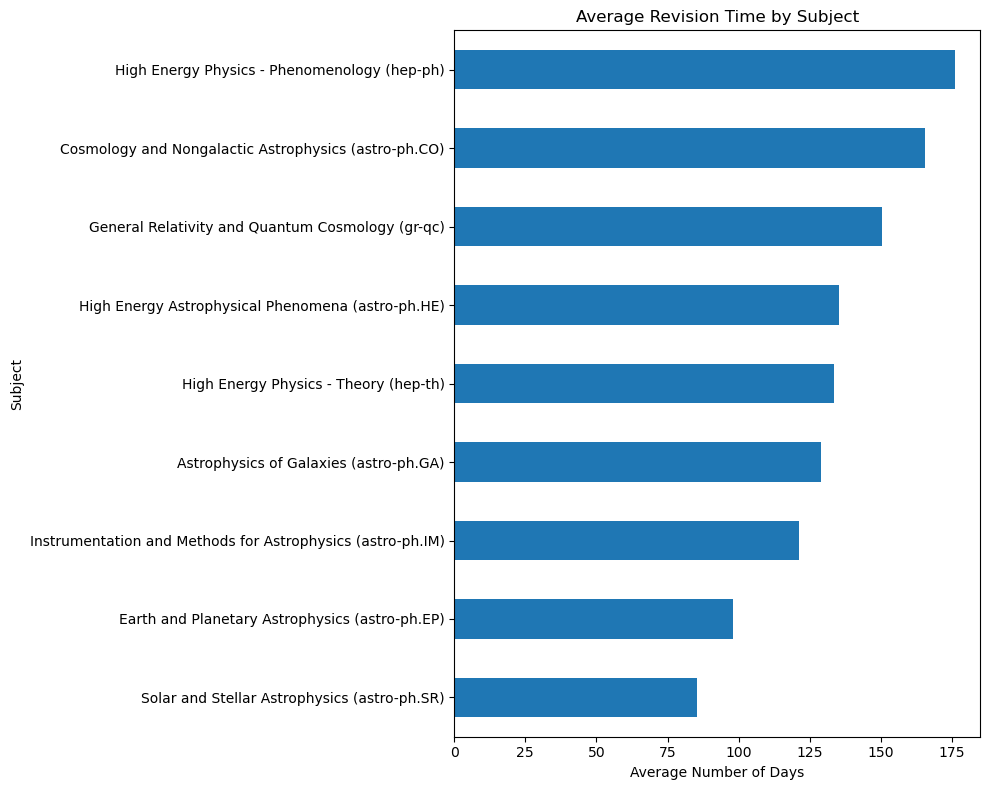

In [7]:
df.loc[df['submission_v1'] == df['submission_most_recent'], 'submission_most_recent'] = pd.NaT


revised_df = df[
    (df['primary_subject'].str.contains('astro-ph', na=False)) |
    (df['primary_subject'].str.contains('gr-qc', na=False)) |
    (df['primary_subject'].str.contains('hep-ph', na=False)) |
    (df['primary_subject'].str.contains('hep-th', na=False))
].copy()


revised_df = revised_df[
    df['submission_v1'].notna() & 
    df['submission_most_recent'].notna()
].copy()
revised_df.info()

revised_df['revision_days'] = (revised_df['submission_most_recent']-revised_df['submission_v1']).dt.days
average_revision_time = revised_df.groupby('primary_subject')['revision_days'].mean().sort_values(ascending=True)

average_revision_time.plot(kind='barh', figsize=(10,8))

plt.title('Average Revision Time by Subject')
plt.xlabel('Average Number of Days')
plt.ylabel('Subject')

plt.tight_layout()

plt.show


### Comparing Collaboration Size With Revision Size

After analyzing the data for the subject vs revision dates and subject vs authors, I had the question of whether or not collaboration size resulted in lower revision times. I started this by creating a scatter plot of the number of authors vs the revision days on the paper. The resulting graph is eclectic and doesn't show much of a trend. There is an extremely weak negative correlation which lead me to try to analyze further to see if I could isolate it.

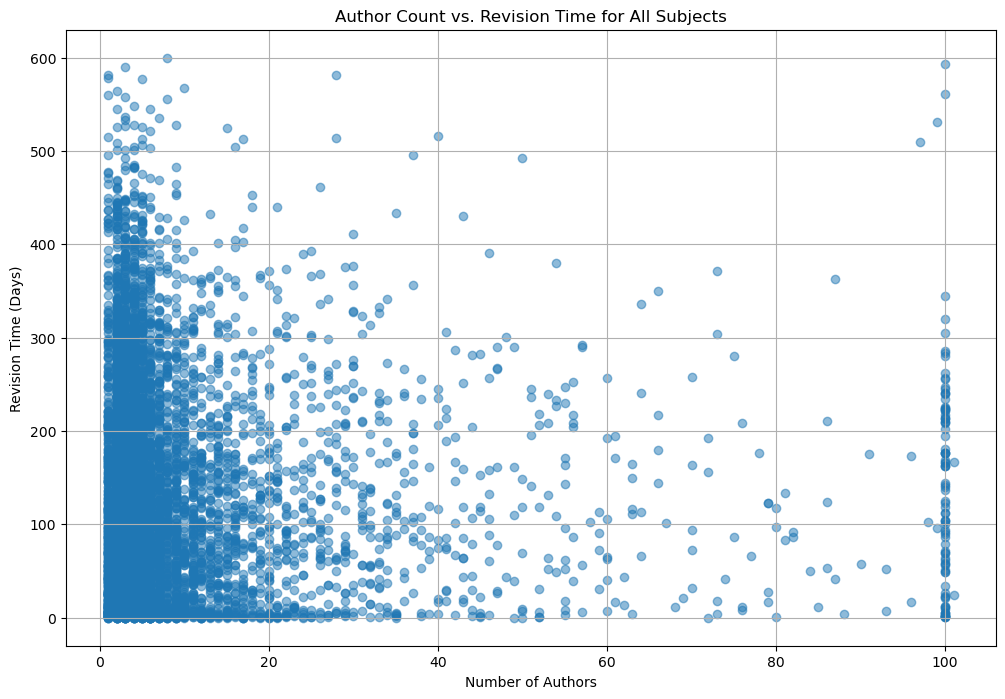

In [8]:
# First, ensure the 'author_count' column exists in the revised_df
revised_df['author_count'] = revised_df['authors'].apply(len)

# Create the scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(revised_df['author_count'], revised_df['revision_days'], alpha=0.5)

# Add a title and labels
plt.title('Author Count vs. Revision Time for All Subjects')
plt.xlabel('Number of Authors')
plt.ylabel('Revision Time (Days)')
plt.grid(True)

plt.show()

I took the data from the original scatter plot and split it by subject using a facetgrid. After splitting the data by subject and then creating scatterplots of Collab size vs Revision time, I noticed the same weak negative correlation (perhaps a little stronger) in the observational and applied fields while there was absolutely no correlation shown for the purely theoretical fields. Overall the data is too thin to be able to determine an actual link.

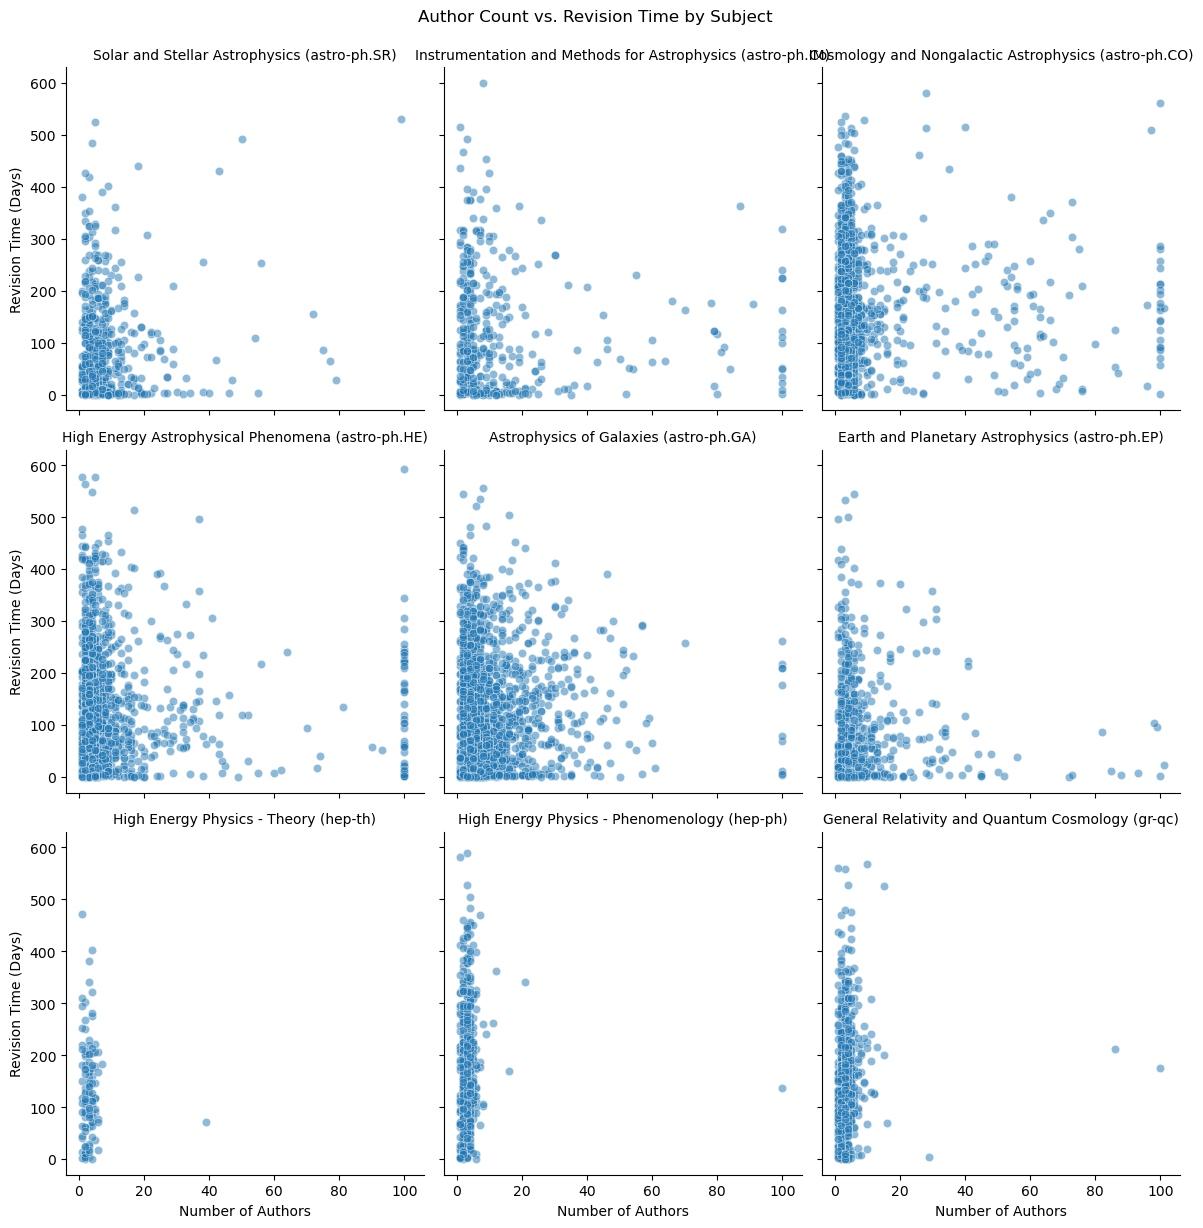

In [11]:
import seaborn as sns

# Create a FacetGrid, telling it to create a separate plot for each 'primary_subject'
g = sns.FacetGrid(revised_df, col="primary_subject", col_wrap=3, height=4)

# Map a scatter plot onto each facet
g.map(sns.scatterplot, "author_count", "revision_days", alpha=0.5)

g.set_titles('{col_name}')

# Add titles and adjust layout
g.fig.suptitle('Author Count vs. Revision Time by Subject', y=1.02)
g.set_axis_labels("Number of Authors", "Revision Time (Days)")

plt.show()

### Calculate The Average Number of Authors on Each Paper by Subject

I had the question of whether different subjects had a consistently different amount of authors per paper. I started once again by filtering the dataframe by subject exclusing the ones that don't fit in well with astrophysics. I then created a column that calculated how many authors each individual paper had. Using .groupby() and .mean() I calculated the average authors per paper and sorted the values in ascending order. I plotted the results on a bar grap and found that instrumentation and Methods for Astrophysics had the highest average authors at near 12 while High Energy Physics - Theory has the lowest average with around 3 authors per paper. The discrepancy between the subjects was not something I expected.

<class 'pandas.core.frame.DataFrame'>
Index: 18426 entries, 0 to 19225
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   title                   18426 non-null  object             
 1   authors                 18426 non-null  object             
 2   link                    18426 non-null  object             
 3   subject                 18426 non-null  object             
 4   doi                     7663 non-null   object             
 5   submission_v1           18426 non-null  datetime64[ns, UTC]
 6   submission_most_recent  7273 non-null   datetime64[ns, UTC]
 7   pdf_link                18426 non-null  object             
 8   primary_subject         18426 non-null  object             
 9   author_counts           18426 non-null  int64              
dtypes: datetime64[ns, UTC](2), int64(1), object(7)
memory usage: 1.5+ MB


<function matplotlib.pyplot.show(close=None, block=None)>

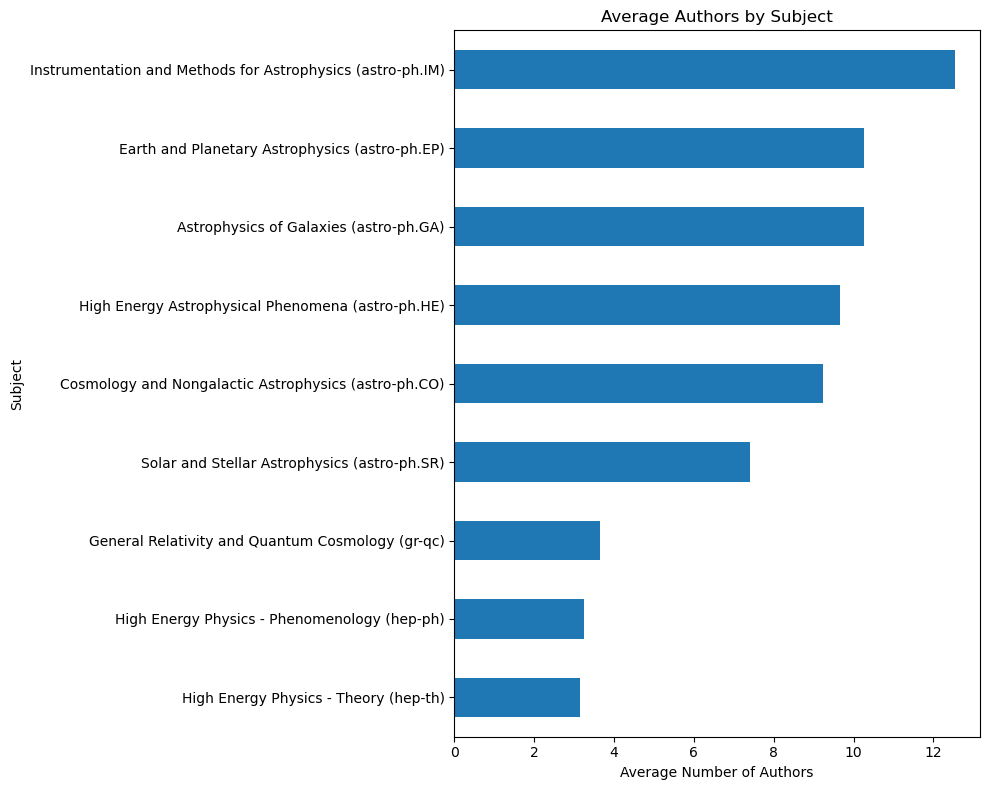

In [10]:
astro_df = df[
    (df['primary_subject'].str.contains('astro-ph', na=False)) |
    (df['primary_subject'].str.contains('gr-qc', na=False)) |
    (df['primary_subject'].str.contains('hep-ph', na=False)) |
    (df['primary_subject'].str.contains('hep-th', na=False))
].copy()

astro_df['author_counts'] = astro_df['authors'].apply(len)
astro_df.info()
average_authors_per_paper = astro_df.groupby('primary_subject')['author_counts'].mean().sort_values(ascending=True)

average_authors_per_paper.plot(kind='barh', figsize=(10,8))

plt.title('Average Authors by Subject')
plt.xlabel('Average Number of Authors')
plt.ylabel('Subject')

plt.tight_layout()

plt.show

## Conclusion

The data analsis of this data revealed a few interesting trends in the data. 
 ### Possible Annual Trend in Publication Months
Looking at the monthly data, there seems to be an interesting trend starting in August and ending in December. The annual low takes place in the month of August which could indicate a trend associated with the start of the fall academic term. The trend continues to peak in October reaching the annual high and then showing a decline as the year enters the winter holidays. This could be a trend showing that people rush to publish papers before the winter holidays. The subsequent dip trending through the winter adds a little more credence to this hypothesis. Further analysis covering multiple years of data would be needed to verify this hypothesis.
 ### Collaboration Size Correlates with Subject Nature

The data reveals a strong correlation between the average number of authors on a paper and the nature of the research field.

 - **Observational/Experimental Fields:** Subjects like "Instrumentation and Methods for Astrophysics" and "Astrophysics of Galaxies" show the highest average number of authors. This is consistent with the nature of observational and experimental work, which often requires large, collaborative teams to operate complex instruments and analyze massive datasets.

 - **Theoretical Fields:** Conversely, subjects like "High Energy Physics - Theory" and "General Relativity and Quantum Cosmology" have the smallest average team sizes. This reflects the nature of theoretical work, which is often conducted by individuals or small groups.

 - **Phenomenology as a Bridge:** Notably, "High Energy Physics - Phenomenology," which serves as a bridge between pure theory and experiment, falls neatly in the middle. Its collaboration size is larger than pure theory but smaller than the large-scale experimental and observational fields, perfectly reflecting its hybrid role.

 ### Revision Time by Subject
The analysis reveals a clear and interesting trend: the average time between a paper's first submission and its final revision varies significantly by subject.

 - **Theoretical fields** , such as "High Energy Physics - Phenomenology" and "Cosmology and Nongalactic Astrophysics," exhibit the longest revision times. This is likely due to the nature of theoretical work, where peer review can be a lengthy process of meticulously checking complex mathematical derivations. Revisions may require substantial reworking of foundational concepts, taking months to complete.

 - **Observational and applied fields**, like "Solar and Stellar Astrophysics," show the shortest revision cycles. This may be because the research is more data-centric, and revisions are more likely to involve re-running an analysis or clarifying methods, which is typically faster than reworking a fundamental theory. A common reason for a revision in these fields is also to simply add the final journal publication details after acceptance.

Interestingly, the data suggests an inverse correlation when compared to the collaboration size analysis; the fields with the fewest authors tend to have the longest revision periods.
 ### Author Count vs. Revision Time
To investigate the hypothesis that a higher author count might lead to a shorter revision time (due to more "internal" peer review), a correlation analysis was performed.

 - **Overall Trend:** An initial scatter plot of all subjects combined showed the data was too eclectic to draw a meaningful conclusion, likely due to the confounding effect of different research types (theoretical vs. observational) being plotted together.

 - **Analysis by Subject:** By creating a faceted plot to view the correlation within each subject individually, a more nuanced picture emerges.

    Some observational/applied fields show a weak negative correlation, suggesting that for these types of projects, a larger team may indeed contribute to a faster revision cycle.

    However, the theoretical fields (such as Theoretical High Energy Physics and General Relativity and Quantum Cosmology) show almost no correlation. This is a significant finding in itself, suggesting that for theoretical work, the revision timeline is likely independent of the number of authors and is driven by other factors, such as the inherent complexity of the topic or the nature of the peer-review process for theoretical papers.
 